<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/weatherandprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Weather-aware gas processing and power generation with NeqSim

**Audience.** Process, energy, and operations engineers who know basic Python and want to
connect ambient weather to gas-processing power, fuel use, and emissions.

**Prerequisites.** Familiarity with pressure, temperature, mass flow, compression, and
steady-state process simulation. No previous Meteostat or NeqSim experience is required.

This notebook preserves the original Trondheim weather, station, hourly-data, air-property,
and forecast examples. The default run uses deterministic synthetic weather so a clean Colab
runtime is reproducible without network access. Set `USE_LIVE_WEATHER = True` to request current
public data; a documented fallback remains available if the service cannot be reached.


## Learning objectives, engineering context, and tools

After completing the notebook you can:

1. retrieve daily and hourly weather data, with a reproducible offline fallback;
2. identify a nearby observation station and inspect forecast-like intervals;
3. use NeqSim 3.16.0 to calculate equilibrium air density over an ambient envelope;
4. build an SRK natural-gas stream and an export compressor in a `ProcessSystem`;
5. connect compressor power to a native `GasTurbineUnit`;
6. quantify ambient-temperature and pressure effects on available power, fuel, and direct
   emissions; and
7. verify mass, energy, capacity, and trend checks before using the workflow in a study.

The public packages are [Meteostat](https://dev.meteostat.net/python),
[MET Norway Locationforecast](https://pypi.org/project/metno-locationforecast/), and
[NeqSim](https://github.com/equinor/neqsim). Weather-service responses can change or be
temporarily unavailable, so this tutorial separates live data acquisition from the deterministic
engineering calculation.


In [1]:
from datetime import datetime, timedelta
import importlib.util
from importlib.metadata import version
import math
import platform
import subprocess
import sys

required_packages = {
    "neqsim": "neqsim",
    "meteostat": "meteostat",
    "metno_locationforecast": "metno-locationforecast",
}
missing_packages = [
    distribution_name
    for module_name, distribution_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *missing_packages,
        ]
    )
else:
    print("Required public-PyPI packages are already available.")

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from IPython.display import display

from meteostat import Point
from meteostat import daily as meteostat_daily
from meteostat import hourly as meteostat_hourly
from meteostat import stations as meteostat_stations
from metno_locationforecast import Forecast, Place
from neqsim import jneqsim

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

USE_LIVE_WEATHER = False
RANDOM_SEED = 20260729

print(f"Python: {platform.python_version()}")
print(f"NeqSim: {version('neqsim')}")
print(f"Live weather requested: {USE_LIVE_WEATHER}")


Required public-PyPI packages are already available.
Python: 3.12.13
NeqSim: 3.16.0
Live weather requested: False


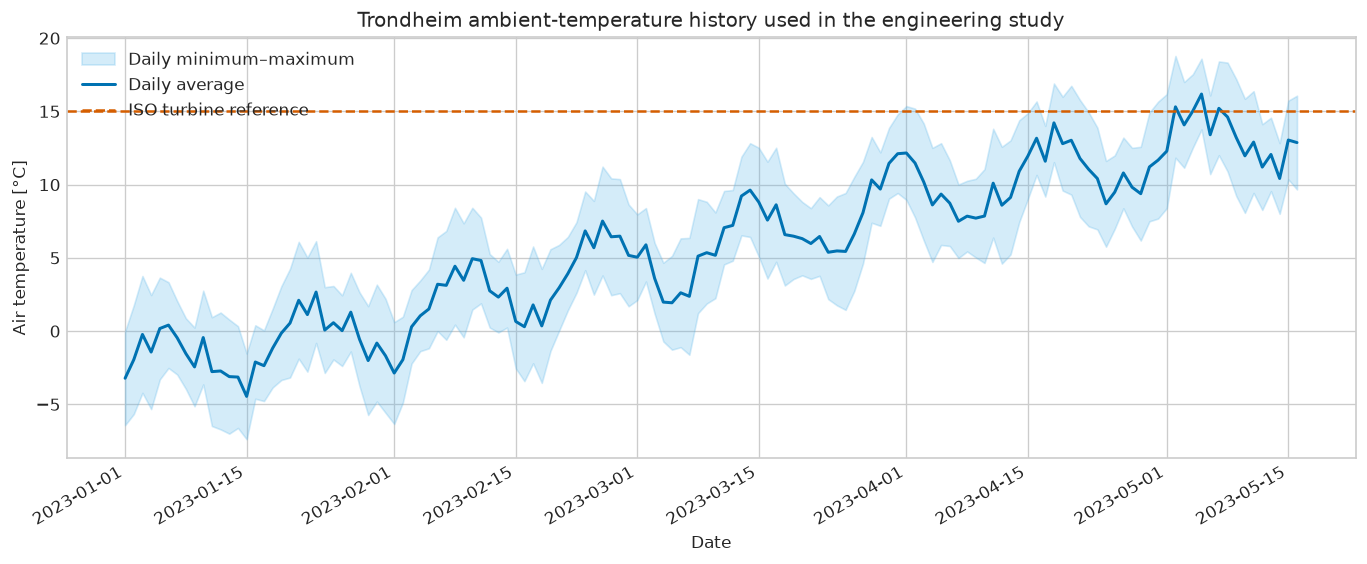

In [2]:
# Preserve the original Trondheim daily-weather example with a deterministic fallback.
start = datetime(2023, 1, 1)
end = datetime(2023, 5, 16)
trondheim = Point(63.446827, 10.421906, 70)


def make_synthetic_daily_weather(start_date, end_date, seed):
    index = pd.date_range(start_date, end_date, freq="D")
    day_number = np.arange(len(index), dtype=float)
    rng = np.random.default_rng(seed)
    seasonal_temperature_c = -3.0 + 0.13 * day_number
    synoptic_temperature_c = 2.4 * np.sin(2.0 * np.pi * day_number / 17.0)
    average_temperature_c = (
        seasonal_temperature_c
        + synoptic_temperature_c
        + rng.normal(0.0, 0.8, len(index))
    )
    daily_range_c = 3.2 + 0.8 * np.sin(2.0 * np.pi * day_number / 9.0)
    pressure_hpa = (
        1012.0
        + 11.0 * np.sin(2.0 * np.pi * day_number / 12.0)
        + rng.normal(0.0, 1.5, len(index))
    )
    wind_speed_kmh = np.clip(
        16.0 + 7.0 * np.sin(2.0 * np.pi * day_number / 8.0)
        + rng.normal(0.0, 2.0, len(index)),
        2.0,
        None,
    )
    precipitation_mm = np.where(
        np.sin(2.0 * np.pi * day_number / 7.0) > 0.35,
        rng.uniform(0.2, 6.0, len(index)),
        0.0,
    )
    return pd.DataFrame(
        {
            "tavg": average_temperature_c,
            "tmin": average_temperature_c - daily_range_c,
            "tmax": average_temperature_c + daily_range_c,
            "prcp": precipitation_mm,
            "wspd": wind_speed_kmh,
            "pres": pressure_hpa,
        },
        index=index,
    )


weather_source = "deterministic synthetic Trondheim-like data"

if USE_LIVE_WEATHER:
    try:
        daily_weather = meteostat_daily(
            trondheim,
            start,
            end,
        ).fetch()
        required_columns = {"tavg", "tmin", "tmax", "pres"}

        if daily_weather.empty or not required_columns.issubset(daily_weather.columns):
            raise ValueError("The public daily response is empty or incomplete.")

        weather_source = "Meteostat daily observations"
    except Exception as error:
        print(f"Live daily data unavailable; using the fallback: {error}")
        daily_weather = make_synthetic_daily_weather(
            start,
            end,
            RANDOM_SEED,
        )
else:
    daily_weather = make_synthetic_daily_weather(
        start,
        end,
        RANDOM_SEED,
    )

figure, axis = plt.subplots(figsize=(11.5, 4.8))
axis.fill_between(
    daily_weather.index,
    daily_weather["tmin"],
    daily_weather["tmax"],
    color="#56B4E9",
    alpha=0.25,
    label="Daily minimum–maximum",
)
axis.plot(
    daily_weather.index,
    daily_weather["tavg"],
    color="#0072B2",
    linewidth=1.8,
    label="Daily average",
)
axis.axhline(15.0, color="#D55E00", linestyle="--", label="ISO turbine reference")
axis.set_title("Trondheim ambient-temperature history used in the engineering study")
axis.set_xlabel("Date")
axis.set_ylabel("Air temperature [°C]")
axis.legend(loc="upper left")
figure.autofmt_xdate()
plt.tight_layout()
plt.show()


In [3]:
daily_summary = daily_weather[
    ["tavg", "tmin", "tmax", "pres", "wspd", "prcp"]
].describe().T
daily_summary.columns = [
    "Count",
    "Mean",
    "Std. dev.",
    "Minimum",
    "25%",
    "Median",
    "75%",
    "Maximum",
]

print(f"Weather source: {weather_source}")
display(daily_summary.round(3))


Weather source: deterministic synthetic Trondheim-like data


,Count,Mean,Std. dev.,Minimum,25%,Median,75%,Maximum
tavg,136.0,5.767,5.300,-4.454,1.106,5.936,10.217,16.183
tmin,136.0,2.567,5.360,-7.380,-2.000,2.602,7.142,13.771
tmax,136.0,8.967,5.301,-1.528,4.239,9.078,13.221,18.784
pres,136.0,1012.175,7.887,998.919,1004.446,1012.944,1020.125,1024.757
wspd,136.0,15.835,5.402,5.332,11.156,15.271,20.693,25.295
prcp,136.0,1.361,1.845,0.000,0.000,0.000,2.676,5.514


## Nearby weather station

The original notebook searched for a nearby Trondheim station. That capability is retained.
Station metadata are useful for elevation, observation period, and data-quality checks. The
deterministic fallback uses WMO `01271` as a teaching identifier and does not claim that the
synthetic values are observations from that station.


In [4]:
station_source = "documented fallback metadata"

if USE_LIVE_WEATHER:
    try:
        station = meteostat_stations.nearby(
            trondheim,
            limit=1,
        )

        if station.empty:
            raise ValueError("No nearby station was returned.")

        station_source = "Meteostat station metadata"
    except Exception as error:
        print(f"Live station search unavailable; using the fallback: {error}")
        station = pd.DataFrame(
            {
                "name": ["Trondheim teaching station"],
                "country": ["NO"],
                "region": ["Trøndelag"],
                "wmo": ["01271"],
                "latitude": [63.446827],
                "longitude": [10.421906],
                "elevation": [70.0],
            },
            index=["SYNTH"],
        )
else:
    station = pd.DataFrame(
        {
            "name": ["Trondheim teaching station"],
            "country": ["NO"],
            "region": ["Trøndelag"],
            "wmo": ["01271"],
            "latitude": [63.446827],
            "longitude": [10.421906],
            "elevation": [70.0],
        },
        index=["SYNTH"],
    )

print(f"Station source: {station_source}")
display(station)


Station source: documented fallback metadata


,name,country,region,wmo,latitude,longitude,elevation
SYNTH,Trondheim teaching station,NO,Trøndelag,01271,63.446827,10.421906,70.0


In [5]:
stationid = str(station.iloc[0]["wmo"])

assert stationid
print(f"Station identifier used for the hourly example: {stationid}")


Station identifier used for the hourly example: 01271


## Hourly data and operational variability

Hourly conditions reveal short temperature ramps that daily averages hide. These ramps matter
when available generation is close to process demand. Temperature is in °C, pressure in hPa,
wind speed in km/h, and precipitation in mm/h.


In [6]:
hourly_start = datetime(2023, 5, 1)
hourly_end = datetime(2023, 5, 13, 23, 59)


def make_synthetic_hourly_weather(start_date, end_date, seed):
    index = pd.date_range(start_date, end_date, freq="h")
    hour_number = np.arange(len(index), dtype=float)
    rng = np.random.default_rng(seed)
    temperature_c = (
        8.0
        + 4.5 * np.sin(2.0 * np.pi * (hour_number - 7.0) / 24.0)
        + 1.4 * np.sin(2.0 * np.pi * hour_number / (24.0 * 4.0))
        + rng.normal(0.0, 0.25, len(index))
    )
    pressure_hpa = (
        1013.0
        + 7.0 * np.sin(2.0 * np.pi * hour_number / (24.0 * 5.0))
    )
    wind_speed_kmh = np.clip(
        13.0
        + 5.0 * np.sin(2.0 * np.pi * hour_number / 18.0)
        + rng.normal(0.0, 1.0, len(index)),
        1.0,
        None,
    )
    precipitation_mm = np.where(
        np.sin(2.0 * np.pi * hour_number / 37.0) > 0.85,
        0.4,
        0.0,
    )
    return pd.DataFrame(
        {
            "temp": temperature_c,
            "pres": pressure_hpa,
            "wspd": wind_speed_kmh,
            "prcp": precipitation_mm,
        },
        index=index,
    )


hourly_source = "deterministic synthetic Trondheim-like data"

if USE_LIVE_WEATHER:
    try:
        hourly_weather = meteostat_hourly(
            stationid,
            hourly_start,
            hourly_end,
        ).fetch()
        required_columns = {"temp", "pres"}

        if hourly_weather.empty or not required_columns.issubset(hourly_weather.columns):
            raise ValueError("The public hourly response is empty or incomplete.")

        hourly_source = "Meteostat hourly observations"
    except Exception as error:
        print(f"Live hourly data unavailable; using the fallback: {error}")
        hourly_weather = make_synthetic_hourly_weather(
            hourly_start,
            hourly_end,
            RANDOM_SEED + 1,
        )
else:
    hourly_weather = make_synthetic_hourly_weather(
        hourly_start,
        hourly_end,
        RANDOM_SEED + 1,
    )

print(f"Hourly source: {hourly_source}")
display(hourly_weather.head().round(3))


Hourly source: deterministic synthetic Trondheim-like data


,temp,pres,wspd,prcp
2023-05-01 00:00:00,3.991,1013.000,11.959,0.0
2023-05-01 01:00:00,3.808,1013.366,14.945,0.0
2023-05-01 02:00:00,4.030,1013.732,15.651,0.0
2023-05-01 03:00:00,4.214,1014.095,17.358,0.0
2023-05-01 04:00:00,5.490,1014.455,15.435,0.0


## Power production and the effect of ambient conditions

The original section created an air fluid but did not calculate power. We retain the air-property
calculation, correct the dry-air composition, and extend the example to an export compressor and
NeqSim's native `GasTurbineUnit`. The process calculation is steady state for each weather point;
weather supplies boundary conditions, not a dynamic equipment model.


In [7]:
# The former NeqSim 2.5.35 pin is replaced by the single current-PyPI setup above.
runtime_versions = pd.Series(
    {
        "NeqSim": version("neqsim"),
        "Python": platform.python_version(),
        "Weather mode": (
            "live with fallback" if USE_LIVE_WEATHER else "deterministic fallback"
        ),
    },
    name="Runtime",
)
display(runtime_versions.to_frame())


,Runtime
NeqSim,3.16.0
Python,3.12.13
Weather mode,deterministic fallback


In [8]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)

dry_air_composition = {
    "nitrogen": 0.78084,
    "oxygen": 0.20946,
    "argon": 0.00934,
    "CO2": 0.00036,
}


def make_air(temperature_c, pressure_bara):
    air = SystemSrkEos(temperature_c + 273.15, pressure_bara)

    for component_name, mole_fraction in dry_air_composition.items():
        air.addComponent(component_name, mole_fraction)

    air.setMixingRule("classic")
    operations = ThermodynamicOperations(air)
    operations.TPflash()
    air.init(0)
    air.init(1)
    air.initPhysicalProperties()
    return air


reference_air = make_air(15.0, 1.01325)
reference_air_results = pd.Series(
    {
        "Temperature [°C]": reference_air.getTemperature("C"),
        "Pressure [bara]": reference_air.getPressure("bara"),
        "Density [kg/m³]": reference_air.getDensity("kg/m3"),
        "Molar mass [kg/mol]": reference_air.getMolarMass("kg/mol"),
        "Enthalpy [J/kg]": reference_air.getEnthalpy("J/kg"),
    },
    name="NeqSim SRK dry air",
)
display(reference_air_results.to_frame().round(6))


,NeqSim SRK dry air
Temperature [°C],15.000000
Pressure [bara],1.013250
Density [kg/m³],1.225392
Molar mass [kg/mol],0.028966
Enthalpy [J/kg],29815.686420


## Forecasting weather and process simulation

The original MET Norway forecast example is retained behind the same `USE_LIVE_WEATHER` switch.
The default forecast-like frame is derived deterministically from the hourly example, so every
downstream NeqSim result is reproducible. In an operating application, archive the provider,
retrieval time, forecast issue time, and quality flags before making decisions.


In [9]:
# metno-locationforecast was installed once in the shared setup cell.
forecast_place = Place(
    "Trondheim",
    63.446827,
    10.421906,
    70,
)
forecast_user_agent = (
    "neqsim-colab-weather-process/1.0 "
    "https://github.com/EvenSol/NeqSim-Colab"
)


In [10]:
forecast_source = "deterministic forecast-like continuation"
live_forecast = None

if USE_LIVE_WEATHER:
    try:
        live_forecast = Forecast(
            forecast_place,
            forecast_user_agent,
        )
        live_forecast.update()
        first_interval = live_forecast.data.intervals[0]
        forecast_source = "MET Norway Locationforecast"
    except Exception as error:
        print(f"Live forecast unavailable; using the fallback: {error}")
        live_forecast = None

if live_forecast is None:
    forecast_index = pd.date_range(
        hourly_weather.index[-1] + timedelta(hours=1),
        periods=24,
        freq="h",
    )
    forecast_hour = np.arange(24, dtype=float)
    forecast_frame = pd.DataFrame(
        {
            "air_temperature_c": (
                9.0
                + 4.0 * np.sin(2.0 * np.pi * (forecast_hour - 7.0) / 24.0)
            ),
            "air_pressure_hpa": (
                1010.0
                + 2.5 * np.sin(2.0 * np.pi * forecast_hour / 24.0)
            ),
            "wind_speed_m_s": (
                4.0
                + 1.2 * np.sin(2.0 * np.pi * forecast_hour / 12.0)
            ),
        },
        index=forecast_index,
    )
    first_interval = forecast_frame.iloc[0].to_dict()

print(f"Forecast source: {forecast_source}")


Forecast source: deterministic forecast-like continuation


In [11]:
print("First forecast interval:")
print(first_interval)

if live_forecast is None:
    display(forecast_frame.head(6).round(3))


First forecast interval:
{'air_temperature_c': 5.136296694843727, 'air_pressure_hpa': 1010.0, 'wind_speed_m_s': 4.0}


,air_temperature_c,air_pressure_hpa,wind_speed_m_s
2023-05-14 00:00:00,5.136,1010.000,4.000
2023-05-14 01:00:00,5.000,1010.647,4.600
2023-05-14 02:00:00,5.136,1011.250,5.039
2023-05-14 03:00:00,5.536,1011.768,5.200
2023-05-14 04:00:00,6.172,1012.165,5.039
2023-05-14 05:00:00,7.000,1012.415,4.600


## 1. Governing relationships, units, and assumptions

For a low-pressure gas, density should approach the ideal-gas limit:

$$

\rho = \frac{p M}{Z R T}

$$

Here $\rho$ is density in kg/m³, $p$ is absolute pressure in Pa, $M$ is molar
mass in kg/mol, $Z$ is compressibility factor, $R$ is the gas constant in
J/(mol K), and $T$ is absolute temperature in K.

Compressor shaft power is checked against the steady-flow enthalpy rise:

$$

\dot{W} = \dot{m} (h_{\mathrm{out}} - h_{\mathrm{in}})

$$

The workflow assumes dry air, a steady SRK equilibrium state at each weather point, a fixed
natural-gas feed composition, steady compressor efficiency, and the performance curves embedded
in NeqSim's turbine catalog. It does not model icing, inlet-filter loss, humidity, wind loading,
combustion dynamics, grid dispatch, or equipment thermal inertia.


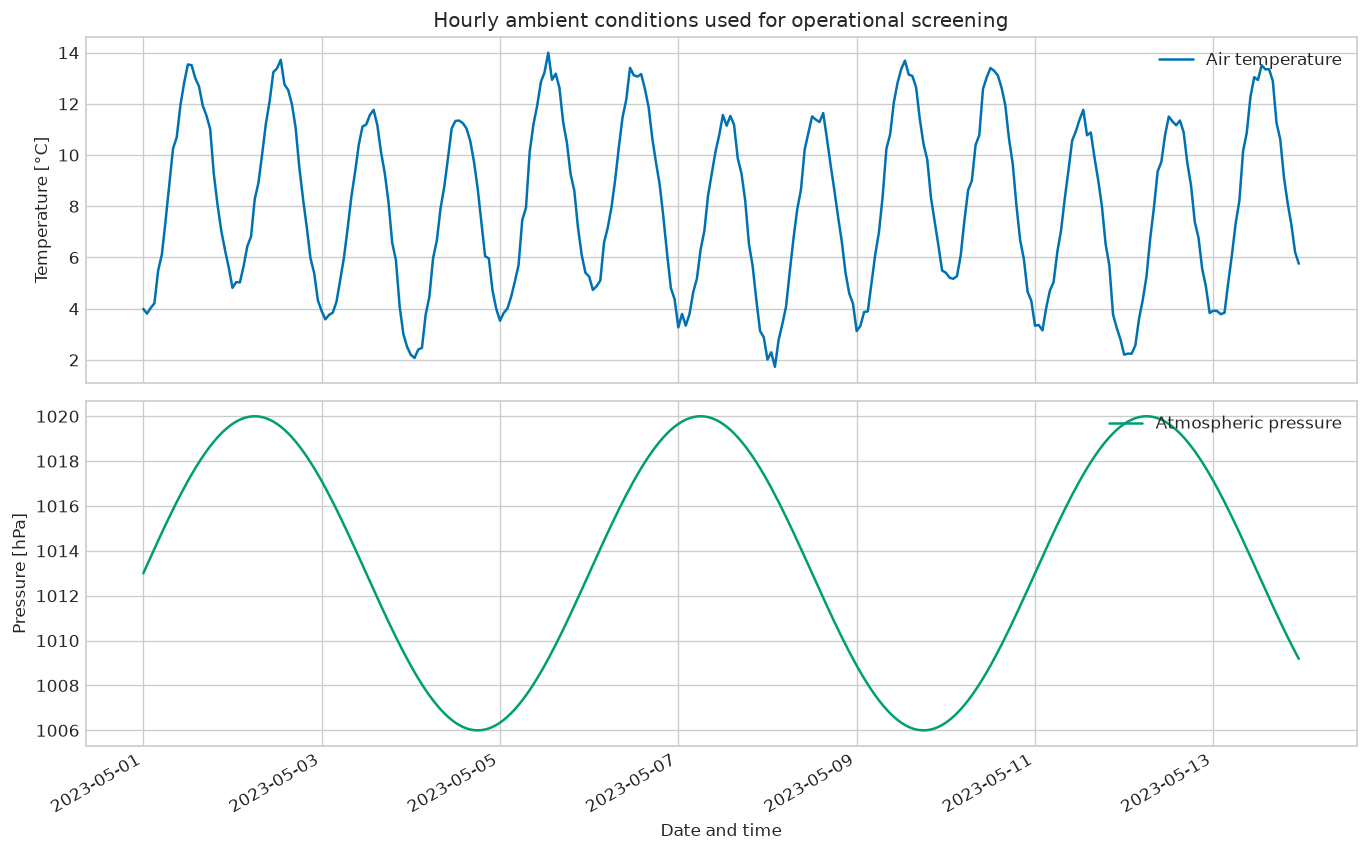

In [12]:
figure, axes = plt.subplots(2, 1, figsize=(11.5, 7.2), sharex=True)
axes[0].plot(
    hourly_weather.index,
    hourly_weather["temp"],
    color="#0072B2",
    label="Air temperature",
)
axes[0].set_title("Hourly ambient conditions used for operational screening")
axes[0].set_ylabel("Temperature [°C]")
axes[0].legend(loc="upper right")

axes[1].plot(
    hourly_weather.index,
    hourly_weather["pres"],
    color="#009E73",
    label="Atmospheric pressure",
)
axes[1].set_xlabel("Date and time")
axes[1].set_ylabel("Pressure [hPa]")
axes[1].legend(loc="upper right")

figure.autofmt_xdate()
plt.tight_layout()
plt.show()


The hourly figure shows the difference between a short diurnal cycle and the slower pressure
cycle. Both variables are retained because turbine air mass capacity depends on inlet density.
The synthetic series is deliberately smooth enough to make expected trends auditable; it is not
presented as a historical Trondheim measurement.


In [13]:
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
GasTurbineCatalog = (
    jneqsim.process.equipment.powergeneration.gasturbine.GasTurbineCatalog
)
GasTurbineUnit = (
    jneqsim.process.equipment.powergeneration.gasturbine.GasTurbineUnit
)

fuel_composition = {
    "nitrogen": 0.015,
    "CO2": 0.020,
    "methane": 0.885,
    "ethane": 0.055,
    "propane": 0.018,
    "i-butane": 0.003,
    "n-butane": 0.004,
}


def make_natural_gas(
    temperature_c=25.0,
    pressure_bara=55.0,
    flow_kg_h=80_000.0,
):
    fluid = SystemSrkEos(temperature_c + 273.15, pressure_bara)

    for component_name, mole_fraction in fuel_composition.items():
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(flow_kg_h, "kg/hr")
    operations = ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.init(0)
    fluid.init(1)
    fluid.initPhysicalProperties()
    return fluid


### How NeqSim represents this workflow

- `SystemSrkEos` stores composition, temperature, pressure, phases, and the SRK property model.
- `ThermodynamicOperations.TPflash()` solves phase equilibrium at specified $T$ and $p$.
- `Stream` carries the fluid state and flow rate into equipment.
- `Compressor` solves the outlet state at specified pressure and isentropic efficiency.
- `GasTurbineUnit` converts demanded process power into fuel, emissions, and capacity results
  using a released NeqSim turbine specification.
- `ProcessSystem.run()` orders and executes connected unit operations.

The classic SRK mixing rule is appropriate for a hydrocarbon-rich screening fluid. The example is
not a calibrated custody-transfer or vendor-performance model.


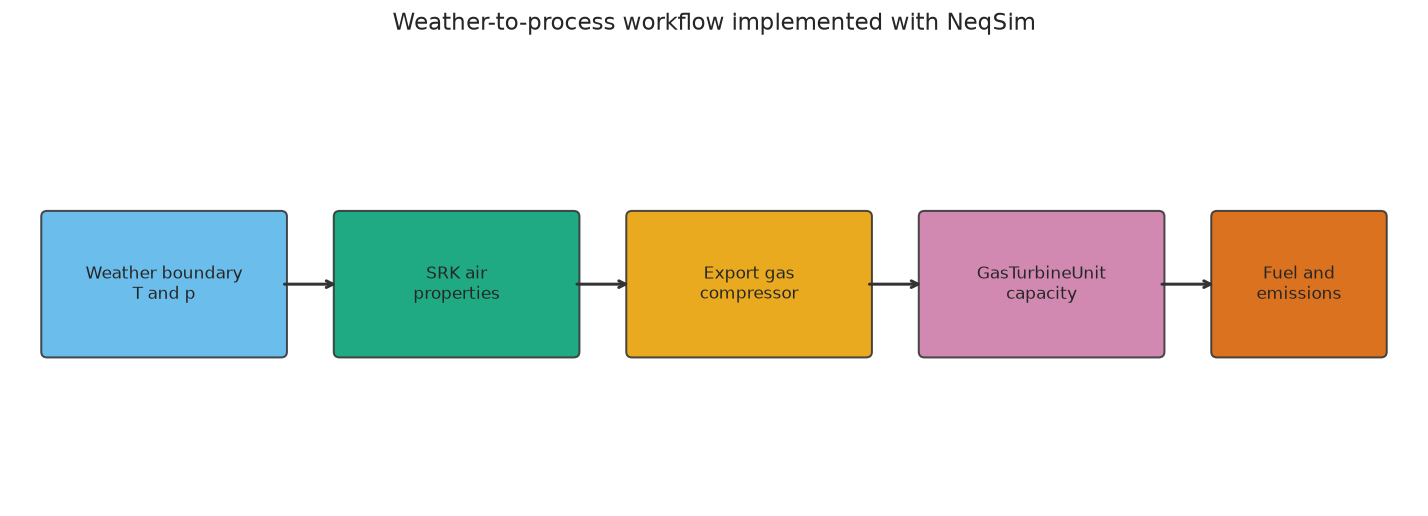

In [14]:
figure, axis = plt.subplots(figsize=(12.0, 4.4))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 4.0)
axis.axis("off")

workflow_boxes = [
    (0.3, 1.35, 2.0, 1.2, "Weather boundary\nT and p", "#56B4E9"),
    (2.8, 1.35, 2.0, 1.2, "SRK air\nproperties", "#009E73"),
    (5.3, 1.35, 2.0, 1.2, "Export gas\ncompressor", "#E69F00"),
    (7.8, 1.35, 2.0, 1.2, "GasTurbineUnit\ncapacity", "#CC79A7"),
    (10.3, 1.35, 1.4, 1.2, "Fuel and\nemissions", "#D55E00"),
]

for x_position, y_position, width, height, label, color in workflow_boxes:
    patch = FancyBboxPatch(
        (x_position, y_position),
        width,
        height,
        boxstyle="round,pad=0.05",
        facecolor=color,
        edgecolor="#333333",
        linewidth=1.2,
        alpha=0.88,
    )
    axis.add_patch(patch)
    axis.text(
        x_position + width / 2.0,
        y_position + height / 2.0,
        label,
        ha="center",
        va="center",
        fontsize=10,
    )

for x_start, x_end in [(2.3, 2.8), (4.8, 5.3), (7.3, 7.8), (9.8, 10.3)]:
    axis.annotate(
        "",
        xy=(x_end, 1.95),
        xytext=(x_start, 1.95),
        arrowprops={"arrowstyle": "->", "color": "#333333", "lw": 1.8},
    )

axis.set_title(
    "Weather-to-process workflow implemented with NeqSim",
    fontsize=14,
    pad=14,
)
plt.tight_layout()
plt.show()


The workflow keeps the data boundary explicit: weather data set the ambient state, while NeqSim
calculates fluid properties, process demand, turbine capacity, fuel use, and emissions. This
separation makes it possible to replace the synthetic weather frame with a controlled plant-data
interface without rewriting the process model.


In [15]:
air_screen_rows = []

for temperature_c in [-15.0, -5.0, 5.0, 15.0, 25.0, 35.0]:
    for pressure_hpa in [980.0, 1013.25, 1040.0]:
        air = make_air(
            temperature_c=temperature_c,
            pressure_bara=pressure_hpa / 1000.0,
        )
        ideal_density_kg_m3 = (
            pressure_hpa
            * 100.0
            * air.getMolarMass("kg/mol")
            / (8.314462618 * (temperature_c + 273.15))
        )
        air_screen_rows.append(
            {
                "Temperature [°C]": temperature_c,
                "Pressure [hPa]": pressure_hpa,
                "NeqSim density [kg/m³]": air.getDensity("kg/m3"),
                "Ideal density [kg/m³]": ideal_density_kg_m3,
            }
        )

air_screen = pd.DataFrame(air_screen_rows)
air_screen["Relative density difference [%]"] = (
    100.0
    * (
        air_screen["NeqSim density [kg/m³]"]
        - air_screen["Ideal density [kg/m³]"]
    )
    / air_screen["Ideal density [kg/m³]"]
)
display(air_screen.round(5))


,Temperature [°C],Pressure [hPa],NeqSim density [kg/m³],Ideal density [kg/m³],Relative density difference [%]
0,-15.0,980.00,1.32342,1.32252,0.06845
1,-15.0,1013.25,1.36836,1.36739,0.07076
2,-15.0,1040.00,1.40451,1.40349,0.07262
3,-5.0,980.00,1.27387,1.27320,0.05320
4,-5.0,1013.25,1.31712,1.31639,0.05499
5,-5.0,1040.00,1.35191,1.35115,0.05644
6,5.0,980.00,1.22792,1.22742,0.04013
7,5.0,1013.25,1.26959,1.26907,0.04149
8,5.0,1040.00,1.30313,1.30257,0.04257
9,15.0,980.00,1.18517,1.18483,0.02891


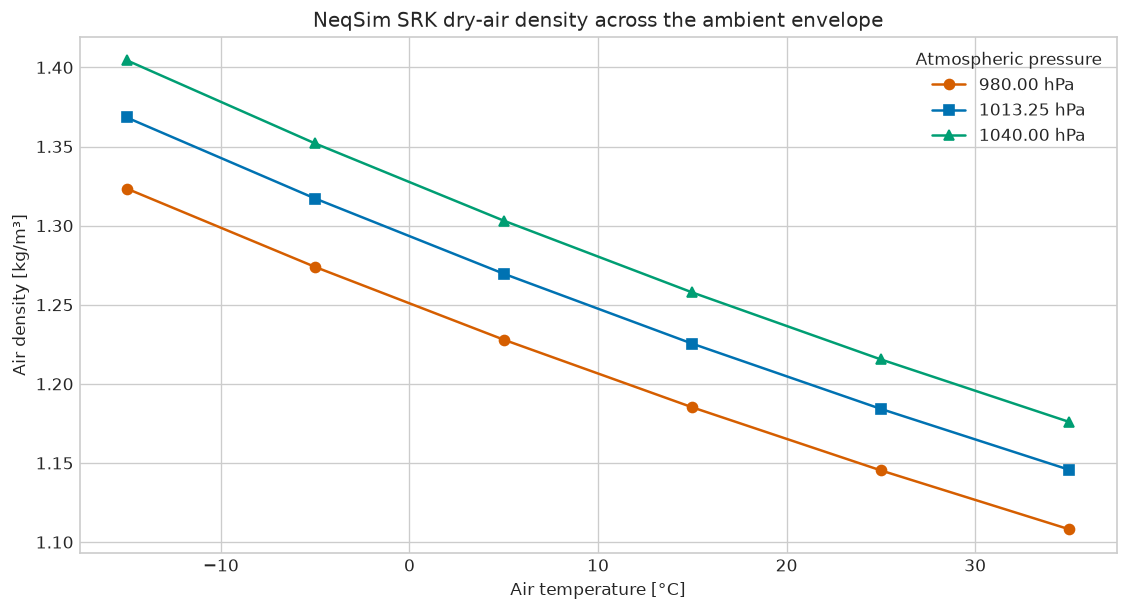

In [16]:
figure, axis = plt.subplots(figsize=(9.5, 5.2))

for pressure_hpa, color, marker in [
    (980.0, "#D55E00", "o"),
    (1013.25, "#0072B2", "s"),
    (1040.0, "#009E73", "^"),
]:
    subset = air_screen[air_screen["Pressure [hPa]"] == pressure_hpa]
    axis.plot(
        subset["Temperature [°C]"],
        subset["NeqSim density [kg/m³]"],
        color=color,
        marker=marker,
        label=f"{pressure_hpa:.2f} hPa",
    )

axis.set_title("NeqSim SRK dry-air density across the ambient envelope")
axis.set_xlabel("Air temperature [°C]")
axis.set_ylabel("Air density [kg/m³]")
axis.legend(title="Atmospheric pressure")
plt.tight_layout()
plt.show()


Air density decreases with temperature and increases with atmospheric pressure, as required by
the ideal-gas limiting case. The small NeqSim-versus-ideal difference is expected at near-ambient
pressure; the SRK calculation becomes more important when the same workflow is extended to
pressurized gas streams.


## 2. Compressor demand and turbine response

For each steady weather point the process compressor establishes demanded shaft power. The turbine
then evaluates whether that demand is feasible at the specified ambient state. Direct carbon
dioxide rate is reported by the turbine model:

$$

\dot{m}_{\mathrm{CO_2}} =
\dot{m}_{\mathrm{fuel}} f_{\mathrm{CO_2}}

$$

Here $\dot{m}_{\mathrm{CO_2}}$ and $\dot{m}_{\mathrm{fuel}}$ are in kg/h, and
$f_{\mathrm{CO_2}}$ is the model-derived carbon conversion factor in kg CO₂ per kg fuel.
The native equipment model also reports load, effective heat rate, NOₓ, exhaust flow, and
available power.


In [17]:
selected_turbine_model = "CENTAUR_50"
selected_turbine_specification = GasTurbineCatalog.get(selected_turbine_model)


def simulate_export_compressor(
    flow_kg_h=80_000.0,
    inlet_pressure_bara=55.0,
    outlet_pressure_bara=120.0,
    isentropic_efficiency=0.78,
):
    feed_fluid = make_natural_gas(
        temperature_c=25.0,
        pressure_bara=inlet_pressure_bara,
        flow_kg_h=flow_kg_h,
    )
    feed = Stream("weather-study feed", feed_fluid)
    compressor = Compressor("weather-study export compressor", feed)
    compressor.setOutletPressure(outlet_pressure_bara, "bara")
    compressor.setIsentropicEfficiency(isentropic_efficiency)
    process = ProcessSystem("weather-aware export process")
    process.add(feed)
    process.add(compressor)
    process.run()

    outlet = compressor.getOutletStream()
    mass_flow_kg_s = feed.getFlowRate("kg/sec")
    enthalpy_rate_change_w = mass_flow_kg_s * (
        outlet.getFluid().getEnthalpy("J/kg")
        - feed.getFluid().getEnthalpy("J/kg")
    )
    result = {
        "Mass flow [kg/h]": feed.getFlowRate("kg/hr"),
        "Inlet pressure [bara]": feed.getPressure("bara"),
        "Outlet pressure [bara]": outlet.getPressure("bara"),
        "Outlet temperature [°C]": outlet.getTemperature("C"),
        "Power [MW]": compressor.getPower("W") / 1.0e6,
        "Mass residual [kg/h]": (
            feed.getFlowRate("kg/hr")
            - outlet.getFlowRate("kg/hr")
        ),
        "Energy residual [W]": (
            compressor.getPower("W")
            - enthalpy_rate_change_w
        ),
    }
    objects = {
        "feed": feed,
        "compressor": compressor,
        "outlet": outlet,
        "process": process,
    }
    return result, objects


def simulate_turbine(
    demanded_power_mw,
    ambient_temperature_c,
    ambient_pressure_hpa,
):
    fuel_fluid = make_natural_gas(
        temperature_c=15.0,
        pressure_bara=25.0,
        flow_kg_h=1_000.0,
    )
    fuel_stream = Stream("weather-study fuel", fuel_fluid)
    turbine = GasTurbineUnit(
        "weather-study turbine",
        fuel_stream,
        selected_turbine_specification,
    )
    turbine.setAmbientTemperatureK(ambient_temperature_c + 273.15)
    turbine.setAmbientPressureBara(ambient_pressure_hpa / 1000.0)
    turbine.setDemandedPower(demanded_power_mw * 1.0e6)
    turbine.run()

    result = {
        "Ambient temperature [°C]": ambient_temperature_c,
        "Ambient pressure [hPa]": ambient_pressure_hpa,
        "Demand [MW]": demanded_power_mw,
        "Available power [MW]": turbine.getAvailablePowerW() / 1.0e6,
        "Load [%]": 100.0 * turbine.getLoadFraction(),
        "Thermal efficiency [%]": (
            100.0 * turbine.getThermalEfficiency()
        ),
        "Fuel [kg/h]": turbine.getFuelMassFlowKgPerHr(),
        "Direct CO2 [kg/h]": turbine.getCO2EmissionKgPerHr(),
        "Direct CO2 intensity [kg/MWh]": (
            turbine.getCO2IntensityKgPerMWh()
        ),
        "NOx [kg/h]": turbine.getNOxEmissionKgPerS() * 3600.0,
        "Power shortfall [MW]": turbine.getPowerShortfallW() / 1.0e6,
        "Below minimum load": turbine.isBelowMinLoad(),
        "Overloaded": turbine.isOverloaded(),
    }
    return result, turbine


In [18]:
compressor_result, compressor_objects = simulate_export_compressor()
compressor_table = pd.Series(
    compressor_result,
    name="Export-compression base case",
).to_frame()
display(compressor_table.round(6))

assert abs(compressor_result["Mass residual [kg/h]"]) < 1.0e-6
assert abs(compressor_result["Energy residual [W]"]) < 1.0e-5
assert compressor_result["Outlet temperature [°C]"] > 25.0
assert 0.0 < compressor_result["Power [MW]"] < 10.0

print("Compressor mass, energy, temperature, and power checks passed.")


Compressor mass, energy, temperature, and power checks passed.


,Export-compression base case
Mass flow [kg/h],80000.000000
Inlet pressure [bara],55.000000
Outlet pressure [bara],120.000000
Outlet temperature [°C],96.019219
Power [MW],2.982955
Mass residual [kg/h],0.000000
Energy residual [W],0.000000


The export compressor is the practical process-power consumer. Its NeqSim outlet enthalpy rise
matches reported shaft power to numerical precision, mass flow is conserved, and compression
raises temperature. These checks are more informative than accepting a converged solver flag
alone.


In [19]:
ambient_temperature_screen_c = np.array(
    [-15.0, -5.0, 5.0, 15.0, 25.0, 35.0],
)
turbine_screen_rows = []

for ambient_temperature_c in ambient_temperature_screen_c:
    for ambient_pressure_hpa in [980.0, 1013.25, 1040.0]:
        result, _ = simulate_turbine(
            demanded_power_mw=compressor_result["Power [MW]"],
            ambient_temperature_c=ambient_temperature_c,
            ambient_pressure_hpa=ambient_pressure_hpa,
        )
        turbine_screen_rows.append(result)

turbine_screen = pd.DataFrame(turbine_screen_rows)
display(
    turbine_screen[
        [
            "Ambient temperature [°C]",
            "Ambient pressure [hPa]",
            "Available power [MW]",
            "Load [%]",
            "Fuel [kg/h]",
            "Direct CO2 [kg/h]",
            "Power shortfall [MW]",
        ]
    ].round(5)
)


,Ambient temperature [°C],Ambient pressure [hPa],Available power [MW],Load [%],Fuel [kg/h],Direct CO2 [kg/h],Power shortfall [MW]
0,-15.0,980.00,5.11641,58.30174,825.88640,2172.56746,0.0
1,-15.0,1013.25,5.29000,56.38856,835.62503,2198.18579,0.0
2,-15.0,1040.00,5.42966,54.93818,843.44220,2218.74954,0.0
3,-5.0,980.00,4.89396,60.95182,818.44373,2152.98886,0.0
4,-5.0,1013.25,5.06000,58.95167,827.75322,2177.47829,0.0
5,-5.0,1040.00,5.19358,57.43537,835.28833,2197.30007,0.0
6,5.0,980.00,4.67150,63.85429,811.10512,2133.68398,0.0
7,5.0,1013.25,4.83000,61.75890,819.83895,2156.65909,0.0
8,5.0,1040.00,4.95751,60.17038,826.98741,2175.46376,0.0
9,15.0,980.00,4.44905,67.04700,804.14391,2115.37191,0.0


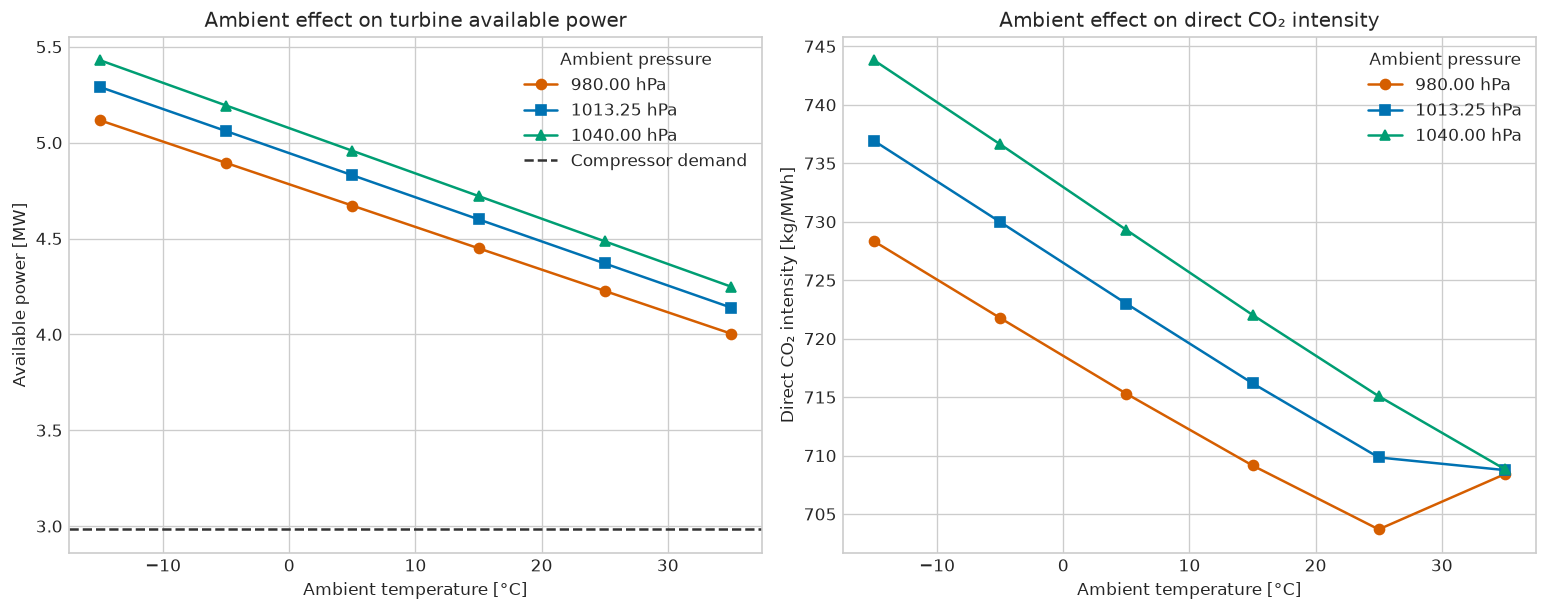

In [20]:
figure, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))

for pressure_hpa, color, marker in [
    (980.0, "#D55E00", "o"),
    (1013.25, "#0072B2", "s"),
    (1040.0, "#009E73", "^"),
]:
    subset = turbine_screen[
        turbine_screen["Ambient pressure [hPa]"] == pressure_hpa
    ]
    axes[0].plot(
        subset["Ambient temperature [°C]"],
        subset["Available power [MW]"],
        color=color,
        marker=marker,
        label=f"{pressure_hpa:.2f} hPa",
    )
    axes[1].plot(
        subset["Ambient temperature [°C]"],
        subset["Direct CO2 intensity [kg/MWh]"],
        color=color,
        marker=marker,
        label=f"{pressure_hpa:.2f} hPa",
    )

axes[0].axhline(
    compressor_result["Power [MW]"],
    color="#333333",
    linestyle="--",
    label="Compressor demand",
)
axes[0].set_title("Ambient effect on turbine available power")
axes[0].set_xlabel("Ambient temperature [°C]")
axes[0].set_ylabel("Available power [MW]")
axes[0].legend(title="Ambient pressure")

axes[1].set_title("Ambient effect on direct CO₂ intensity")
axes[1].set_xlabel("Ambient temperature [°C]")
axes[1].set_ylabel("Direct CO₂ intensity [kg/MWh]")
axes[1].legend(title="Ambient pressure")

plt.tight_layout()
plt.show()


Higher ambient temperature reduces available power in the released turbine model. Higher
atmospheric pressure increases air density and available power. The dashed line is the constant
compressor demand; intersections identify weather conditions where a capacity margin can become
small. At fixed demand, colder or higher-pressure air also lowers turbine load fraction; the
catalog model's part-load heat-rate curve can therefore increase fuel and CO₂ intensity even while
capacity improves. This is a screening result, not a vendor guarantee.


## 3. Final application: daily weather-to-fuel and emissions workflow

The final application reuses the same process objects and evaluates every daily weather point.
It retrieves model results, checks capacity, identifies limiting days, and produces an operations
table that can be exported to a historian or planning tool. A real implementation should validate
timestamps, missing values, forecast age, and measurement quality before running the model.


In [21]:
daily_application_rows = []

for timestamp, weather_row in daily_weather.iterrows():
    turbine_result, _ = simulate_turbine(
        demanded_power_mw=compressor_result["Power [MW]"],
        ambient_temperature_c=float(weather_row["tavg"]),
        ambient_pressure_hpa=float(weather_row["pres"]),
    )
    daily_application_rows.append(
        {
            "Timestamp": timestamp,
            **turbine_result,
            "Capacity margin [MW]": (
                turbine_result["Available power [MW]"]
                - turbine_result["Demand [MW]"]
            ),
        }
    )

daily_application = pd.DataFrame(daily_application_rows).set_index("Timestamp")
display(daily_application.head().round(5))


,Ambient temperature [°C],Ambient pressure [hPa],Demand [MW],Available power [MW],Load [%],Thermal efficiency [%],Fuel [kg/h],Direct CO2 [kg/h],Direct CO2 intensity [kg/MWh],NOx [kg/h],Power shortfall [MW],Below minimum load,Overloaded,Capacity margin [MW]
Timestamp,,,,,,,,,,,,,,
2023-01-01,-3.21729,1014.26183,2.98295,5.02401,59.37398,28.23834,826.62188,2174.50219,728.97595,2.33541,0.0,False,False,2.04106
2023-01-02,-1.94951,1014.99404,2.98295,4.99843,59.67786,28.26585,825.81739,2172.38591,728.26649,2.32795,0.0,False,False,2.01547
2023-01-03,-0.22555,1021.21526,2.98295,4.98910,59.78941,28.25429,826.15528,2173.27478,728.56448,2.32523,0.0,False,False,2.00615
2023-01-04,-1.42971,1023.68299,2.98295,5.02914,59.31343,28.19790,827.80731,2177.62059,730.02136,2.33691,0.0,False,False,2.04618
2023-01-05,0.17745,1020.58835,2.98295,4.97670,59.93837,28.27127,825.65905,2171.96939,728.12686,2.32161,0.0,False,False,1.99375


In [22]:
reference_pressure_screen = turbine_screen[
    turbine_screen["Ambient pressure [hPa]"] == 1013.25
].sort_values("Ambient temperature [°C]")
available_power_series = reference_pressure_screen[
    "Available power [MW]"
].to_numpy()

air_pressure_subset = air_screen[
    air_screen["Temperature [°C]"] == 15.0
].sort_values("Pressure [hPa]")
air_pressure_density = air_pressure_subset[
    "NeqSim density [kg/m³]"
].to_numpy()
reference_temperature_screen = turbine_screen[
    turbine_screen["Ambient temperature [°C]"] == 15.0
].sort_values("Ambient pressure [hPa]")
available_power_by_pressure = reference_temperature_screen[
    "Available power [MW]"
].to_numpy()

assert np.all(np.diff(available_power_series) < 0.0)
assert np.all(np.diff(air_pressure_density) > 0.0)
assert np.all(np.diff(available_power_by_pressure) > 0.0)
assert daily_application["Available power [MW]"].notna().all()
assert daily_application["Fuel [kg/h]"].gt(0.0).all()
assert daily_application["Direct CO2 [kg/h]"].gt(0.0).all()
assert daily_application["Power shortfall [MW]"].ge(0.0).all()
assert daily_application["Capacity margin [MW]"].min() > 0.0
assert not daily_application["Below minimum load"].any()
assert not daily_application["Overloaded"].any()

print("Ambient trends, finite outputs, emissions, and capacity checks passed.")


Ambient trends, finite outputs, emissions, and capacity checks passed.


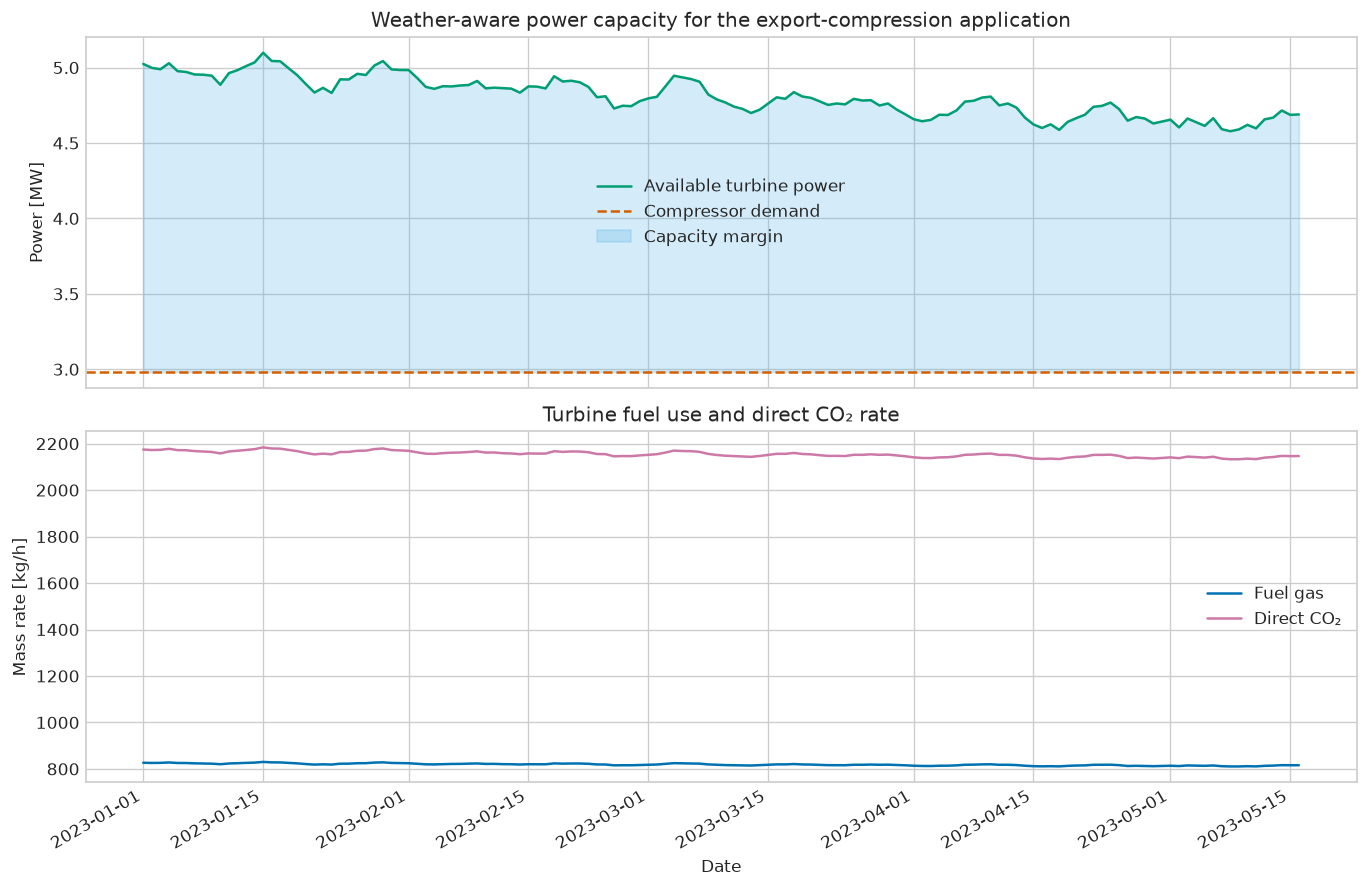

In [23]:
figure, axes = plt.subplots(2, 1, figsize=(11.5, 7.5), sharex=True)
axes[0].plot(
    daily_application.index,
    daily_application["Available power [MW]"],
    color="#009E73",
    label="Available turbine power",
)
axes[0].axhline(
    compressor_result["Power [MW]"],
    color="#D55E00",
    linestyle="--",
    label="Compressor demand",
)
axes[0].fill_between(
    daily_application.index,
    compressor_result["Power [MW]"],
    daily_application["Available power [MW]"],
    color="#56B4E9",
    alpha=0.25,
    label="Capacity margin",
)
axes[0].set_title("Weather-aware power capacity for the export-compression application")
axes[0].set_ylabel("Power [MW]")
axes[0].legend(loc="best")

axes[1].plot(
    daily_application.index,
    daily_application["Fuel [kg/h]"],
    color="#0072B2",
    label="Fuel gas",
)
axes[1].plot(
    daily_application.index,
    daily_application["Direct CO2 [kg/h]"],
    color="#CC79A7",
    label="Direct CO₂",
)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Mass rate [kg/h]")
axes[1].set_title("Turbine fuel use and direct CO₂ rate")
axes[1].legend(loc="best")

figure.autofmt_xdate()
plt.tight_layout()
plt.show()


The integrated figure shows that process demand is fixed in this study while turbine capacity and
fuel performance respond to weather. The minimum capacity margin is the useful operating
screening metric. Fuel and direct CO₂ vary less than available power here because demanded power
is unchanged and the case stays within the turbine's feasible operating range.


In [24]:
limiting_timestamp = daily_application["Capacity margin [MW]"].idxmin()
best_timestamp = daily_application["Capacity margin [MW]"].idxmax()

extreme_cases = daily_application.loc[
    [limiting_timestamp, best_timestamp],
    [
        "Ambient temperature [°C]",
        "Ambient pressure [hPa]",
        "Demand [MW]",
        "Available power [MW]",
        "Capacity margin [MW]",
        "Fuel [kg/h]",
        "Direct CO2 [kg/h]",
    ],
].copy()
extreme_cases.index = ["Minimum margin", "Maximum margin"]
display(extreme_cases.round(5))


,Ambient temperature [°C],Ambient pressure [hPa],Demand [MW],Available power [MW],Capacity margin [MW],Fuel [kg/h],Direct CO2 [kg/h]
Minimum margin,14.61712,1006.52549,2.98295,4.57822,1.59526,810.75978,2132.77554
Maximum margin,-4.45406,1023.48206,2.98295,5.09841,2.11546,830.19297,2183.89626


### Verification checklist

- The preserved daily, station, hourly, air-property, and forecast examples all execute.
- The SRK dry-air density follows temperature and pressure limiting trends.
- Compressor mass and steady-flow energy balances close.
- Turbine available power decreases with ambient temperature at constant pressure.
- Every daily application result is finite, has positive fuel and emissions, and has no power
  shortfall for the selected case.
- All displayed quantities use explicit SI or SI-derived units.


In [25]:
maximum_air_ideal_difference_percent = air_screen[
    "Relative density difference [%]"
].abs().max()
maximum_compressor_mass_residual_kg_h = abs(
    compressor_result["Mass residual [kg/h]"]
)
maximum_compressor_energy_residual_w = abs(
    compressor_result["Energy residual [W]"]
)
minimum_capacity_margin_mw = daily_application[
    "Capacity margin [MW]"
].min()

assert maximum_air_ideal_difference_percent < 1.0
assert maximum_compressor_mass_residual_kg_h < 1.0e-6
assert maximum_compressor_energy_residual_w < 1.0e-5
assert minimum_capacity_margin_mw > 0.0
assert len(daily_application) == len(daily_weather)

print("Final engineering validation passed.")
print(
    "Maximum SRK–ideal air-density difference: "
    f"{maximum_air_ideal_difference_percent:.6f} %"
)
print(
    "Maximum compressor mass residual: "
    f"{maximum_compressor_mass_residual_kg_h:.3e} kg/h"
)
print(
    "Maximum compressor energy residual: "
    f"{maximum_compressor_energy_residual_w:.3e} W"
)
print(f"Minimum turbine capacity margin: {minimum_capacity_margin_mw:.6f} MW")


Final engineering validation passed.
Maximum SRK–ideal air-density difference: 0.072625 %
Maximum compressor mass residual: 0.000e+00 kg/h
Maximum compressor energy residual: 0.000e+00 W
Minimum turbine capacity margin: 1.595265 MW


## Troubleshooting

- **Weather request fails:** keep `USE_LIVE_WEATHER = False`, or verify internet access and the
  provider's user-agent and rate-limit requirements.
- **Missing weather columns:** inspect the provider response before renaming or interpolating;
  never silently substitute units.
- **NeqSim import fails in Colab:** rerun the single setup cell, then restart from the first cell.
- **Turbine is overloaded:** reduce process flow or pressure ratio, select a larger catalog model,
  or explicitly study multiple units. Do not clip the shortfall.
- **Unexpected compressor power:** confirm absolute pressure in bara, mass flow in kg/h, and
  isentropic efficiency as a fraction.
- **Non-monotonic weather response:** isolate temperature and pressure before combining them, and
  check whether the case crossed a load or capacity boundary.


## Validity limits and practical limitations

This is a deterministic screening tutorial. The SRK model is suitable for hydrocarbon process
gas and qualitative ambient-air properties, but humidity and condensation are omitted. Turbine
catalog performance is not a substitute for vendor correction curves, guarantee tolerances,
degradation calibration, inlet/exhaust losses, or site-specific fuel limits. The daily loop is a
sequence of independent steady states, not a transient simulation. Direct CO₂ and NOₓ exclude
upstream lifecycle emissions.


## Summary

The repaired notebook now connects reproducible weather inputs to real NeqSim functionality:
SRK air and natural-gas fluids, TP flashes, streams, an export compressor, a process-system solver,
and a catalog-backed gas turbine. The workflow demonstrates how ambient temperature and pressure
affect air density, available power, capacity margin, fuel use, and direct emissions while keeping
data provenance and engineering limitations explicit.


## Further exercises

1. Enable live weather and compare the retrieved period with the deterministic fallback.
2. Add relative humidity and assess when a dry-air assumption becomes inadequate.
3. Repeat the process screen for three export flow rates and identify the first weather-limited
   case.
4. Compare two `GasTurbineCatalog` models at equal process demand.
5. Add `GasTurbineDegradation` and quantify the combined hot-day and fouling penalty.
6. Replace the fixed compressor efficiency with a validated compressor map.
7. Store forecast issue time and calculate a forecast-versus-observation error distribution.


## Authoritative references

- NeqSim source and releases: https://github.com/equinor/neqsim
- NeqSim Java API: https://equinor.github.io/neqsim/javadoc/index.html
- NeqSim Python package: https://pypi.org/project/neqsim/
- Meteostat Python documentation: https://dev.meteostat.net/python
- MET Norway Locationforecast data model:
  https://docs.api.met.no/doc/locationforecast/datamodel
- ISO 2533, *Standard Atmosphere*, for reference atmospheric definitions.
- Moran et al., *Fundamentals of Engineering Thermodynamics*, for steady-flow energy balances.
